<h1>5장 텍스트 클러스터링과 토픽 모델링</h1>
<i>다양한 언어 모델을 사용해 문서를 클러스터링하기.</i>

<a href="https://github.com/ssuai/handson-llm"><img src="https://img.shields.io/badge/GitHub%20Repository-black?logo=github"></a>
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ssuai/handson-llm/blob/main/chapter05.ipynb)

### [선택사항] - Colab에서 패키지 선택하기


이 노트북을 구글 코랩에서 실행한다면 다음 코드 셀을 실행하여 이 노트북에서 필요한 패키지를  설치하세요.

---

💡 **NOTE**: 이 노트북의 코드를 실행하려면 GPU를 사용하는 것이 좋습니다. 구글 코랩에서는 **런타임 > 런타임 유형 변경 > 하드웨어 가속기 > T4 GPU**를 선택하세요.

---


사용 패키지 버전
* transformers 4.57.3
* datasets 4.0.0
* sentence-transformers 5.2.0
* umap-learn 0.5.9.post2
* hdbscan 0.8.41
* bertopic 0.17.4

In [1]:
%%capture
!pip install bertopic

In [2]:
# 깃허브에서 위젯 상태 오류를 피하기 위해 진행 표시줄을 나타내지 않도록 설정합니다.
from transformers.utils import logging

logging.disable_progress_bar()

# 아카이브 논문: 계산 및 언어

In [3]:
# 허깅 페이스에서 데이터를 로드합니다.
from datasets import load_dataset
dataset = load_dataset("maartengr/arxiv_nlp")["train"]

# 데이터를 추출합니다.
abstracts = dataset["Abstracts"]
titles = dataset["Titles"]

In [4]:
titles[0], abstracts[0]

('Introduction to Arabic Speech Recognition Using CMUSphinx System',
 '  In this paper Arabic was investigated from the speech recognition problem\npoint of view. We propose a novel approach to build an Arabic Automated Speech\nRecognition System (ASR). This system is based on the open source CMU Sphinx-4,\nfrom the Carnegie Mellon University. CMU Sphinx is a large-vocabulary;\nspeaker-independent, continuous speech recognition system based on discrete\nHidden Markov Models (HMMs). We build a model using utilities from the\nOpenSource CMU Sphinx. We will demonstrate the possible adaptability of this\nsystem to Arabic voice recognition.\n')

# 텍스트 클러스터링을 위한 파이프라인

## 1. 문서 임베딩

In [5]:
from sentence_transformers import SentenceTransformer

# 각각의 초록에 대한 임베딩을 만듭니다.
embedding_model = SentenceTransformer('thenlper/gte-small')
embeddings = embedding_model.encode(list(abstracts), show_progress_bar=True)

Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

In [6]:
# 만들어진 임베딩의 차원을 확인합니다.
embeddings.shape

(44949, 384)

## 2. 임베딩 차원 축소하기

In [7]:
from umap import UMAP

# 입력 임베딩을 384차원에서 5차원으로 줄입니다.
umap_model = UMAP(
    n_components=5, min_dist=0.0, metric='cosine', random_state=42, n_jobs=1
)
reduced_embeddings = umap_model.fit_transform(embeddings)

In [8]:
reduced_embeddings.shape

(44949, 5)

## 3. 축소된 임베딩 클러스터링

In [9]:
from hdbscan import HDBSCAN

# 모델을 훈련하고 클러스터를 추출합니다.
hdbscan_model = HDBSCAN(min_cluster_size=50).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

# 클러스터 개수를 확인합니다.
len(set(clusters))

159

## 4. 클러스터 조사

클러스터 0에 있는 처음 세 개의 문서를 수동으로 조사합니다:

In [10]:
import numpy as np

# 클러스터 0에 있는 처음 세 개의 문서를 출력합니다
cluster = 0
for index in np.where(clusters==cluster)[0][:3]:
    print(list(abstracts)[index][:300] + "... \n")

  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written fo... 

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign lang... 

  Modern computational linguistic software cannot produce important aspects of
sign language translation. Using some researches we deduce that the majority of
automatic sign language translation systems ignore many aspects when they
generate animation; therefore the interpretation lost the truth inf... 



그다음 시각화를 통해 생성된 클러스터를 이해하기 위해 임베딩을 2차원으로 줄입니다.

In [11]:
import pandas as pd

# 384차원의 임베딩을 2차원으로 줄입니다.
reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric='cosine', random_state=42, n_jobs=1
).fit_transform(embeddings)

# 데이터프레임을 만듭니다.
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]

df.head()

,x,y,title,cluster
0,4.901691,-0.265730,Introduction to Arabic Speech Recognition Usin...,-1
1,4.891844,-0.252776,Arabic Speech Recognition System using CMU-Sph...,-1
2,4.858318,-0.870631,On the Development of Text Input Method - Less...,-1
3,1.011186,-2.165854,Network statistics on early English Syntax: St...,-1
4,3.388901,0.755746,Segmentation and Context of Literary and Music...,85


In [12]:
# 정상치(클러스터)와 이상치를 선택합니다.
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

In [13]:
clusters_df.head()

,x,y,title,cluster
4,3.388901,0.755746,Segmentation and Context of Literary and Music...,85
5,1.459367,-3.166929,International Standard for a Linguistic Annota...,112
6,1.449099,-2.963948,A Formal Model of Dictionary Structure and Con...,112
8,0.198546,-3.168375,Learning Probabilistic Models of Word Sense Di...,127
11,-2.663095,1.894415,Bio-linguistic transition and Baldwin effect i...,94


In [14]:
outliers_df.head()

,x,y,title,cluster
0,4.901691,-0.265730,Introduction to Arabic Speech Recognition Usin...,-1
1,4.891844,-0.252776,Arabic Speech Recognition System using CMU-Sph...,-1
2,4.858318,-0.870631,On the Development of Text Input Method - Less...,-1
3,1.011186,-2.165854,Network statistics on early English Syntax: St...,-1
7,0.192604,-3.344306,Practical Approach to Knowledge-based Question...,-1


### 정적 그래프

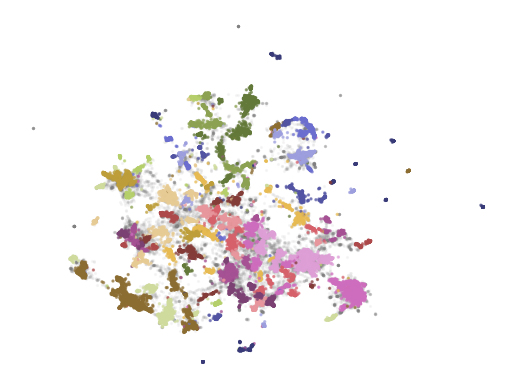

In [15]:
import matplotlib.pyplot as plt

# 이상치와 정상치를 그래프에 나타냅니다.
plt.scatter(outliers_df.x, outliers_df.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    clusters_df.x, clusters_df.y, c=clusters_df.cluster.astype(int),
    alpha=0.6, s=2, cmap='tab20b'
)
plt.axis('off')
plt.show()